# Caracterización y Optimización de Canales Digitales de Alta Velocidad mediante Modelado RC Distribuido

**Proyecto para IEEE INTERCON 2026**  
**Curso:** Señales y Sistemas  
**Autores:** Estudiantes de Ingeniería (Bajo la tutoría del Asesor Senior en Señales y el Equipo de Pedagogía IEEE)

---

## Introducción
Este notebook implementa el modelado físico-matemático avanzado de un canal de transmisión digital de alta velocidad. A diferencia del análisis clásico simplificado de primer orden, aquí consideraremos:
1. **Modelo de Parámetros Distribuidos:** El canal se modela como una línea de transmisión RC distribuida (solución de la ecuación del telégrafo) mediante una aproximación en escalera de orden $N$ en variables de estado.
2. **Modulación de Alto Orden (PAM-4):** Simulación de transmisión binaria unipolar (NRZ) y multinivel (PAM-4) a alta velocidad (28 Gbaud).
3. **Técnicas de Ecualización Activa:** Mitigación de la interferencia intersímbolo (ISI) usando un ecualizador digital en transmisión (TX FFE) y un ecualizador analógico de tiempo continuo en recepción (RX CTLE).
4. **Diseño de Experimentos (DoE) con Muestreo Hipercubo Latino (LHS):** Uso de la librería `pyDOE` para optimizar de forma conjunta los parámetros del co-diseño FFE + CTLE.
5. **Portabilidad Total:** Totalmente compatible y optimizado para ejecutarse de forma directa en **Google Colab**.

In [1]:
# 1. Instalación de dependencias silenciosa en Google Colab
import sys
if 'google.colab' in sys.modules or True: # Habilitado por defecto para asegurar portabilidad
    print("Instalando dependencias necesarias sin alterar la versión de NumPy...")
    try:
        import numpy as _np
        _np_ver = _np.__version__
    except Exception:
        _np_ver = None
    import subprocess
    _cmd = [sys.executable, "-m", "pip", "install", "-q", "pyDOE"]
    if _np_ver:
        _cmd.append(f"numpy=={_np_ver}")
    subprocess.run(_cmd, check=True)

import os
import numpy as np
import scipy.signal as signal
import scipy.fft as fft
from scipy.special import erfc
import matplotlib.pyplot as plt
from pyDOE import lhs

print("Librerías cargadas exitosamente.")

Instalando dependencias necesarias sin alterar la versión de NumPy...
Librerías cargadas exitosamente.


In [2]:
from pyDOE import lhs

## 2. Generación de la Secuencia de Prueba (PRBS)

A diferencia de codificar un texto arbitrario (cuyo flujo de bits es estructurado y no estresa el canal de forma representativa), la caracterización de enlaces de alta velocidad se realiza con una **Secuencia Binaria Pseudoaleatoria (PRBS)**, estándar de facto en la industria (PCIe, Ethernet, OIF-CEI). La PRBS:

- Tiene un espectro plano (aproximadamente blanco) y propiedades estadísticas controladas.
- Contiene las transiciones de peor caso (largas corridas de unos/ceros seguidas de transiciones) que maximizan la interferencia intersímbolo (ISI).
- Es **reproducible** (semilla determinista del LFSR), requisito para resultados publicables.

Generamos la secuencia con un Registro de Desplazamiento con Realimentación Lineal (LFSR) usando polinomios primitivos estándar (p. ej. PRBS15 con período $2^{15}-1$).

In [3]:
def generar_prbs(n_bits, orden=15, semilla=None):
    """
    Genera una Secuencia Binaria Pseudoaleatoria (PRBS) mediante un LFSR de Fibonacci.
    Usa polinomios primitivos estándar de la industria (los mismos de PRBS7..PRBS31).

    Parámetros
    ----------
    n_bits  : número de bits a generar.
    orden   : grado del LFSR (7, 9, 11, 15, 23, 31). PRBS<orden> tiene período 2^orden - 1.
    semilla : estado inicial (lista de 'orden' bits). Por defecto todos a 1 (no-nulo).
    """
    # Taps (posiciones de realimentación) de polinomios primitivos estándar
    TAPS = {7: [7, 6], 9: [9, 5], 11: [11, 9], 15: [15, 14], 23: [23, 18], 31: [31, 28]}
    if orden not in TAPS:
        raise ValueError(f"Orden PRBS no soportado: {orden}. Use uno de {list(TAPS)}.")
    taps = TAPS[orden]

    if semilla is None:
        reg = [1] * orden
    else:
        reg = list(semilla)
        if len(reg) != orden or not any(reg):
            raise ValueError("La semilla debe tener 'orden' bits y no ser nula.")

    bits = np.empty(n_bits, dtype=np.uint8)
    for i in range(n_bits):
        # Salida = último bit del registro
        bits[i] = reg[-1]
        # Realimentación: XOR de los taps seleccionados
        realim = 0
        for t in taps:
            realim ^= reg[t - 1]
        reg = [realim] + reg[:-1]
    return bits

# --- Generación de la secuencia de prueba reproducible ---
# PRBS23: período 2^23 - 1 = 8 388 607 (no se repite en las ventanas usadas y aporta
# más patrones de ISI de peor caso -> estadística del ojo/BER más robusta).
PRBS_ORDEN = 23
N_BITS = 60000            # 30 000 símbolos PAM-4 / 20 000 símbolos PAM-8 disponibles
vector_bits = generar_prbs(N_BITS, orden=PRBS_ORDEN)

# Verificación de balance (una PRBS bien formada es ~50% unos)
balance = vector_bits.mean()
print(f"Secuencia generada: PRBS{PRBS_ORDEN}")
print(f"Bits generados: {len(vector_bits)}")
print(f"Balance de unos: {balance:.4f} (ideal ~0.5)")
print(f"Corrida máxima de ceros consecutivos: "
      f"{max((len(s) for s in ''.join(map(str, vector_bits)).split('1')), default=0)}")

Secuencia generada: PRBS23
Bits generados: 60000
Balance de unos: 0.5023 (ideal ~0.5)
Corrida máxima de ceros consecutivos: 18


## 3. Generación de Señales (Moduladores NRZ y PAM-4)
En esta sección implementamos el formateador de pulsos de banda base. Para PAM-4, agrupamos los bits de dos en dos (Gray mapping) para formar símbolos que toman niveles de voltaje $\{-3, -1, 1, 3\}\text{ V}$.

In [4]:
def modular_nrz(bits, V_high=1.0, V_low=-1.0):
    """Modulación NRZ Bipolar estándar"""
    return np.where(bits == 1, V_high, V_low)

def modular_pam4(bits):
    """Modulación PAM-4 con Gray mapping"""
    # Si el número de bits es impar, rellenar con un cero al final
    if len(bits) % 2 != 0:
        bits = np.append(bits, 0)

    # Reestructurar bits en parejas (dibits)
    dibits = bits.reshape(-1, 2)
    symbols = []
    for d in dibits:
        val = d[0]*2 + d[1]
        # Gray mapping: 00 -> -3V, 01 -> -1V, 11 -> +1V, 10 -> +3V
        if val == 0:     # 00
            symbols.append(-3.0)
        elif val == 1:   # 01
            symbols.append(-1.0)
        elif val == 3:   # 11
            symbols.append(1.0)
        else:            # 10
            symbols.append(3.0)
    return np.array(symbols)

# --- Parámetros de transmisión ---
# TRADE-OFF CENTRAL DEL ESTUDIO: tasa de símbolo vs ancho de banda del canal.
# El canal de referencia (R=80 ohm, C=5 pF, R*C = 400 ps) tiene un ancho de banda
# de solo ~0.95 GHz. Por tanto:
#   * SIN ecualización, el enlace PAM-4 solo es viable si Nyquist (Rs/2) <= ~0.95 GHz,
#     es decir, hasta ~1.9 GBaud (este es el punto de partida sugerido por el usuario).
#   * CON FFE+CTLE (+DFE) se puede operar a tasas MAYORES recuperando la perdida
#     mas alla del -3 dB. El "Barrido de Tasa" al final cuantifica esa ganancia.
#
# Elegimos como punto de operacion del demostrador una tasa donde la ecualizacion
# SI es necesaria (sin EQ cierra, con EQ abre). Es un parametro: ajustalo segun el
# barrido de tasa.
Rs_baud = 4e9               # Tasa de simbolo PAM-4 (Baud). 4 GBaud -> Nyquist 2 GHz (~2x el BW)
Rb = 2 * Rs_baud            # Tasa de bits agregada (2 bit/simbolo en PAM-4)
Tb = 1.0 / Rb
Rs_pam4 = Rs_baud

sps = 32                    # Muestras por símbolo (sobremuestreo para simulación cuasi-continua)
fs = Rs_pam4 * sps          # Frecuencia de muestreo (Hz)
ts = 1.0 / fs

# Ancho de banda -3 dB aproximado de la linea RC distribuida de referencia
RC_ref = 80.0 * 5e-12
BW_canal_GHz = 2.4 / (2 * np.pi * RC_ref) / 1e9
Rs_limite_sinEQ_GBaud = 2 * BW_canal_GHz   # Nyquist = BW  ->  tasa limite sin ecualizar

# Modular
simbolos_nrz = modular_nrz(vector_bits)
simbolos_pam4 = modular_pam4(vector_bits)

print(f"Punto de operacion: PAM-4 a {Rs_baud/1e9:.1f} GBaud "
      f"({Rb/1e9:.1f} Gb/s)  |  Nyquist {Rs_pam4/2e9:.2f} GHz")
print(f"Ancho de banda del canal (-3 dB): ~{BW_canal_GHz:.2f} GHz")
print(f"Tasa maxima sin ecualizacion (Nyquist=BW): ~{Rs_limite_sinEQ_GBaud:.2f} GBaud")
print(f"Cantidad de simbolos PAM-4 disponibles: {len(simbolos_pam4)}")

Punto de operacion: PAM-4 a 4.0 GBaud (8.0 Gb/s)  |  Nyquist 2.00 GHz
Ancho de banda del canal (-3 dB): ~0.95 GHz
Tasa maxima sin ecualizacion (Nyquist=BW): ~1.91 GBaud
Cantidad de simbolos PAM-4 disponibles: 30000


## 4. Modelado Físico-Matemático de la Línea de Transmisión Distribuida
Implementamos la aproximación en variables de estado de un canal RC de parámetros distribuidos de longitud $L$, modelado mediante una cascada de $N$ celdas elementales en escalera.

In [5]:
def crear_canal_rc_distribuido(R_total, C_total, N=5):
    """
    Crea la representación en espacio de estados de una línea de transmisión RC distribuida
    de N etapas en escalera.
    """
    R_seg = R_total / N
    C_seg = C_total / N
    alpha = 1.0 / (R_seg * C_seg)

    # Matriz A de estado (N x N)
    A = np.zeros((N, N))
    for i in range(N-1):
        A[i, i] = -2 * alpha
        A[i, i+1] = alpha
        A[i+1, i] = alpha
    A[N-1, N-1] = -1 * alpha  # Extremo abierto

    # Vector B de entrada
    B = np.zeros((N, 1))
    B[0, 0] = alpha

    # Vector C de salida (obtenemos el voltaje en el último capacitor)
    C = np.zeros((1, N))
    C[0, N-1] = 1.0

    D = np.zeros((1, 1))

    return signal.StateSpace(A, B, C, D)

## 5. Implementación de Ecualizadores (TX FFE y RX CTLE)
El ecualizador en transmisión (FFE) actúa directamente sobre los símbolos digitales discretos como un filtro FIR de 3 coeficientes. El ecualizador en recepción (CTLE) es un filtro lineal analógico continuo $H_{\text{CTLE}}(s)$.

In [6]:
def aplicar_ffe(simbolos, c_pre, c_main, c_post):
    """
    Aplica un filtro FFE (FIR de 3 taps) al flujo de símbolos discretos.
    """
    taps = np.array([c_pre, c_main, c_post])
    # Normalización de potencia para mantener el voltaje constante
    taps = taps / np.sum(np.abs(taps))
    return signal.lfilter(taps, 1.0, simbolos)

def crear_ctle(omega_z, omega_p1, omega_p2, A_dc=1.0):
    """
    Retorna un sistema LTI continuo para el ecualizador analógico CTLE de 1 cero y 2 polos.
    """
    # H(s) = A_dc * (1 + s/omega_z) / [ (1 + s/omega_p1) * (1 + s/omega_p2) ]
    num = [A_dc / omega_z, A_dc]
    den = [1.0 / (omega_p1 * omega_p2), (omega_p1 + omega_p2) / (omega_p1 * omega_p2), 1.0]
    return signal.lti(num, den)

In [7]:
# --- Utilidades de medición, métrica de ojo real y ecualización DFE ---
# Centraliza la lógica usada por el DoE, los escenarios y el barrido de tasa.

NIVELES_PAM4 = np.array([-3.0, -1.0, 1.0, 3.0])

def Q(x):
    """Función de cola Gaussiana Q(x) = 0.5*erfc(x/sqrt(2))."""
    return 0.5 * erfc(np.asarray(x, dtype=float) / np.sqrt(2.0))

def muestrear_alineado(y, tx_syms, sps_val, max_lag=80, n_align=500):
    """
    Alinea la señal recibida con los símbolos transmitidos buscando la fase de
    muestreo (0..sps-1) y el retardo entero de símbolo por correlación cruzada.
    Devuelve (muestras_alineadas, tx_alineados).
    """
    tx = np.asarray(tx_syms, dtype=float)
    n_use = min(len(tx), n_align)
    mejor = None  # (|corr|, fase, lag)
    for fase in range(sps_val):
        ds = y[fase::sps_val]
        n = min(len(ds), n_use)
        if n < 50:
            continue
        a = ds[:n] - ds[:n].mean()
        b = tx[:n] - tx[:n].mean()
        corr = np.correlate(a, b, mode='full')
        lags = np.arange(-n + 1, n)
        m = (lags >= 0) & (lags <= max_lag)
        idx = np.argmax(np.abs(corr[m]))
        score = np.abs(corr[m][idx])
        if mejor is None or score > mejor[0]:
            mejor = (score, fase, int(lags[m][idx]))
    _, fase, lag = mejor
    ds = y[fase::sps_val]
    n = min(len(ds) - lag, len(tx))
    return ds[lag:lag + n], tx[:n]

def estadisticas_niveles(muestras, tx, niveles=NIVELES_PAM4):
    """Media y dispersión (ISI residual) de cada nivel PAM-4 transmitido."""
    mu = np.zeros(4); s = np.zeros(4); cnt = np.zeros(4, dtype=int)
    for k, lv in enumerate(niveles):
        sel = muestras[np.isclose(tx, lv)]
        cnt[k] = len(sel)
        if len(sel) >= 2:
            mu[k] = sel.mean(); s[k] = sel.std()
        elif len(sel) == 1:
            mu[k] = sel[0]
    return mu, s, cnt

def apertura_ojo_real(y, tx, sps_val, k=3.0, n_descartar=60):
    """
    Apertura vertical del PEOR ojo (margen a k-sigma de la ISI residual).
    Es el objetivo correcto del DoE: mide separación entre niveles, NO el
    'spread' de la señal (que premiaba erróneamente la ganancia del CTLE).
    """
    m, t = muestrear_alineado(y, tx, sps_val)
    m, t = m[n_descartar:], t[n_descartar:]
    mu, s, cnt = estadisticas_niveles(m, t)
    if np.any(cnt == 0):
        return -99.0
    o = np.argsort(mu); mu, s = mu[o], s[o]
    ap = (mu[1:] - k*s[1:]) - (mu[:-1] + k*s[:-1])
    return float(np.min(ap))

def respuesta_al_pulso(canal, ctle, c_post, sps_val, ts_val, n_sym=48, pre=6):
    """Respuesta al pulso del enlace (FFE -> canal -> CTLE) a un símbolo unitario."""
    x = np.zeros(n_sym); x[pre] = 1.0
    ffe = aplicar_ffe(x, 0.0, 1.0, c_post)
    xu = np.repeat(ffe, sps_val)
    t = np.arange(len(xu)) * ts_val
    _, yc, _ = signal.lsim(canal, U=xu, T=t)
    _, y, _ = signal.lsim(ctle, U=yc, T=t)
    pico = int(np.argmax(np.abs(y)))     # fase de muestreo = posición del pico
    p = y[pico % sps_val::sps_val]
    c_idx = int(np.argmax(np.abs(p)))    # índice del cursor
    return p, c_idx

def disenar_dfe_zf(canal, ctle, c_post, sps_val, ts_val, n_taps=2):
    """
    Diseña un DFE forzador-de-ceros (ZF) a partir de los post-cursores de la
    respuesta al pulso del enlace. Devuelve coeficientes absolutos (V/símbolo).
    El DFE cancela ISI de cola SIN amplificar ruido (a diferencia del CTLE).
    """
    p, c = respuesta_al_pulso(canal, ctle, c_post, sps_val, ts_val)
    return np.array([p[c + i] if c + i < len(p) else 0.0 for i in range(1, n_taps + 1)])

def _decidir_pam4(yk, escala):
    """Decide el símbolo PAM-4 ideal (-3,-1,1,3) por mínima distancia al nivel escalado."""
    niveles = NIVELES_PAM4 * escala
    return NIVELES_PAM4[int(np.argmin(np.abs(yk - niveles)))]

def evaluar_enlace(y, tx_syms, sps_val, sigma_ruido, dfe_taps=None, n_descartar=80):
    """
    Alinea la señal, opcionalmente aplica un DFE de decisión realimentada,
    y estima BER semi-analítico (modelo Gaussiano) y la apertura del peor ojo.
    """
    m, tx = muestrear_alineado(y, tx_syms, sps_val)
    m, tx = m[n_descartar:], tx[n_descartar:]

    # Ganancia efectiva del enlace (V por unidad de amplitud de símbolo) para el DFE
    mu0, _, _ = estadisticas_niveles(m, tx)
    o0 = np.argsort(mu0)
    escala = (mu0[o0][-1] - mu0[o0][0]) / (NIVELES_PAM4[-1] - NIVELES_PAM4[0])
    escala = escala if escala > 1e-9 else 1.0

    if dfe_taps is not None and len(dfe_taps) > 0:
        Nt = len(dfe_taps)
        hist = [0.0] * Nt
        m_eq = np.empty_like(m)
        for kk in range(len(m)):
            fb = sum(dfe_taps[i] * hist[i] for i in range(Nt))
            yk = m[kk] - fb
            m_eq[kk] = yk
            hist = [_decidir_pam4(yk, escala)] + hist[:-1]  # decisión realimentada
        m = m_eq

    mu, s_isi, cnt = estadisticas_niveles(m, tx)
    o = np.argsort(mu); mu, s_isi, cnt = mu[o], s_isi[o], cnt[o]
    sigma_tot = np.sqrt(s_isi**2 + sigma_ruido**2)
    thr = (mu[:-1] + mu[1:]) / 2.0
    eps = 1e-300
    Pe = np.zeros(4)
    Pe[0] = Q((thr[0] - mu[0]) / (sigma_tot[0] + eps))
    Pe[1] = Q((mu[1] - thr[0]) / (sigma_tot[1] + eps)) + Q((thr[1] - mu[1]) / (sigma_tot[1] + eps))
    Pe[2] = Q((mu[2] - thr[1]) / (sigma_tot[2] + eps)) + Q((thr[2] - mu[2]) / (sigma_tot[2] + eps))
    Pe[3] = Q((mu[3] - thr[2]) / (sigma_tot[3] + eps))
    total = cnt.sum()
    pesos = cnt / total if total > 0 else np.full(4, 0.25)
    ser = float(np.sum(pesos * Pe)); ber = ser / 2.0
    ap = (mu[1:] - 3*s_isi[1:]) - (mu[:-1] + 3*s_isi[:-1])
    return {"ber": ber, "ser": ser, "eye_min": float(np.min(ap)), "mu": mu, "sigma_tot": sigma_tot}

print("Utilidades de medicion, metrica de ojo real y DFE cargadas.")

Utilidades de medicion, metrica de ojo real y DFE cargadas.


In [8]:
# --- Front-end del receptor: ancho de banda finito (anti-alias) ---
# Imprescindible: sin el, el pico de realce del CTLE amplifica ruido fuera de
# banda (10-30 GHz) sin control. Un RX real tiene BW ~ tasa de simbolo.
def aplicar_rx_lpf(y, ts_val, fc_hz, orden=3):
    """Filtro pasa-bajo de entrada del RX (Butterworth, fase cero via filtfilt)."""
    fs_val = 1.0 / ts_val
    wn = min(fc_hz / (fs_val / 2.0), 0.99)
    b, a = signal.butter(orden, wn, btype='low')
    return signal.filtfilt(b, a, y)

print(f"Front-end RX cargado (LPF anti-alias).")

Front-end RX cargado (LPF anti-alias).


## 6. Muestreo Hipercubo Latino (LHS) con pyDOE
Optimizamos sistemáticamente el co-diseño FFE + CTLE para maximizar la apertura vertical del diagrama de ojo.

Corriendo muestreo DoE multivariable (objetivo = apertura de ojo REAL)...
Optimización DoE completa. Mejor apertura de ojo (3-sigma ISI): +2.180 V
Parámetros óptimos -> Cero CTLE: 2.35 GHz, FFE Post-tap: -0.301


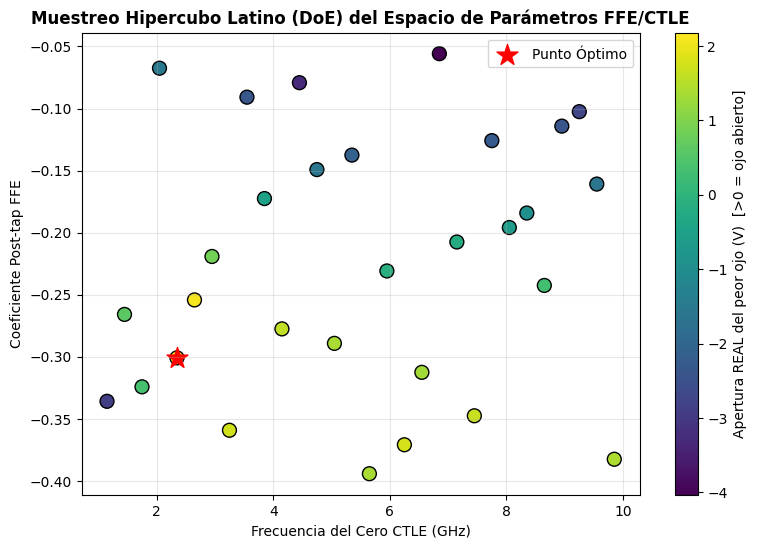

In [9]:
# Rango de búsqueda de diseño (DoE)
np.random.seed(42)
n_muestras = 30
diseño_lhs = lhs(2, samples=n_muestras, criterion='center')

# Mapear a parámetros reales:
# 1. omega_z (frecuencia del cero CTLE) de 1 GHz a 10 GHz
# 2. c_post (coeficiente post-cursor del FFE) de -0.4 a -0.05
omega_z_eval = 2 * np.pi * (1e9 + diseño_lhs[:, 0] * 9e9)
c_post_eval = -0.4 + diseño_lhs[:, 1] * 0.35

# Canal de referencia (R*C = 400 ps -> BW ~0.95 GHz)
R_linea = 80.0
C_linea = 5e-12
canal_lti = crear_canal_rc_distribuido(R_linea, C_linea, N=5)

# El DoE evalua el CTLE viendo el MISMO front-end de RX (LPF) que la etapa de BER,
# para no premiar un realce que solo amplifica ruido fuera de banda.
fc_rx = Rs_pam4

print("Corriendo muestreo DoE multivariable (objetivo = apertura de ojo REAL)...")
mejores_parametros = None
mejor_apertura = -1e9
resultados_aperturas = []

# Secuencia de 600 símbolos para evaluación rápida del DoE
simbolos_prueba = simbolos_pam4[:600]

for i in range(n_muestras):
    w_z = omega_z_eval[i]
    c_p = c_post_eval[i]

    # FFE -> canal -> CTLE -> front-end RX
    ffe_out = aplicar_ffe(simbolos_prueba, c_pre=0.0, c_main=1.0, c_post=c_p)
    x_t_sim = np.repeat(ffe_out, sps)
    t_sim = np.arange(len(x_t_sim)) * ts
    _, y_canal, _ = signal.lsim(canal_lti, U=x_t_sim, T=t_sim)
    ctle_lti = crear_ctle(w_z, omega_p1=2*np.pi*15e9, omega_p2=2*np.pi*30e9, A_dc=2.5)
    _, y_ctle, _ = signal.lsim(ctle_lti, U=y_canal, T=t_sim)
    y_rx = aplicar_rx_lpf(y_ctle, ts, fc_rx)

    # OBJETIVO CORRECTO: margen vertical del peor ojo (separación entre niveles),
    # no el 'spread' de la señal (que premiaba la ganancia del CTLE).
    apert = apertura_ojo_real(y_rx, simbolos_prueba, sps)
    resultados_aperturas.append(apert)

    if apert > mejor_apertura:
        mejor_apertura = apert
        mejores_parametros = (w_z, c_p)

print(f"Optimización DoE completa. Mejor apertura de ojo (3-sigma ISI): {mejor_apertura:+.3f} V")
print(f"Parámetros óptimos -> Cero CTLE: {mejores_parametros[0]/(2*np.pi*1e9):.2f} GHz, "
      f"FFE Post-tap: {mejores_parametros[1]:.3f}")
if mejor_apertura <= 0:
    print("[Aviso] Ningún punto abre el ojo a esta tasa: la EQ lineal no basta -> "
          "considera bajar Rs_baud o añadir DFE (ver barrido de tasa).")

# Graficar el mapa de exploración del espacio de diseño
plt.figure(figsize=(9, 6))
sc = plt.scatter(omega_z_eval / (2*np.pi*1e9), c_post_eval, c=resultados_aperturas,
                 cmap='viridis', s=100, edgecolor='k')
plt.colorbar(sc, label='Apertura REAL del peor ojo (V)  [>0 = ojo abierto]')
plt.scatter(mejores_parametros[0]/(2*np.pi*1e9), mejores_parametros[1],
            color='red', marker='*', s=250, label='Punto Óptimo')
plt.title("Muestreo Hipercubo Latino (DoE) del Espacio de Parámetros FFE/CTLE", fontsize=12, fontweight='bold')
plt.xlabel("Frecuencia del Cero CTLE (GHz)")
plt.ylabel("Coeficiente Post-tap FFE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Simulación Dinámica de los Tres Escenarios Físicos
Simulamos los tres escenarios definidos en la propuesta para evaluar el impacto de la degradación y su posterior mitigación.

In [30]:
# Ventana de símbolos para escenarios y BER (mayor -> estadística de ojo/BER más robusta)
cant_simbolos = 4000
simbolos_nrz_ventana = simbolos_nrz[:cant_simbolos]
simbolos_pam4_ventana = simbolos_pam4[:cant_simbolos]

t_sym = np.arange(cant_simbolos * sps) * ts

# --- ESCENARIO A: Canal Crítico sin Compensación ---
x_a = np.repeat(simbolos_pam4_ventana, sps)
_, y_a, _ = signal.lsim(canal_lti, U=x_a, T=t_sym)

# --- ESCENARIO B: Ecualización Parcial (Solo FFE en Transmisión) ---
ffe_b = aplicar_ffe(simbolos_pam4_ventana, c_pre=0.0, c_main=1.0, c_post=mejores_parametros[1])
x_b = np.repeat(ffe_b, sps)
_, y_b, _ = signal.lsim(canal_lti, U=x_b, T=t_sym)

# --- ESCENARIO C: Co-diseño Óptimo (FFE + CTLE) ---
# Mismos parámetros óptimos hallados con el LHS de pyDOE
ffe_c = aplicar_ffe(simbolos_pam4_ventana, c_pre=0.0, c_main=1.0, c_post=mejores_parametros[1])
x_c = np.repeat(ffe_c, sps)
_, y_c_canal, _ = signal.lsim(canal_lti, U=x_c, T=t_sym)

ctle_opt = crear_ctle(mejores_parametros[0], omega_p1=2*np.pi*15e9, omega_p2=2*np.pi*30e9, A_dc=2.5)
_, y_c, _ = signal.lsim(ctle_opt, U=y_c_canal, T=t_sym)

print(f"Simulación completada para todos los escenarios ({cant_simbolos} símbolos).")

Simulación completada para todos los escenarios (4000 símbolos).


## 8. Análisis Gráfico de la Respuesta Transitoria y Diagramas de Ojo

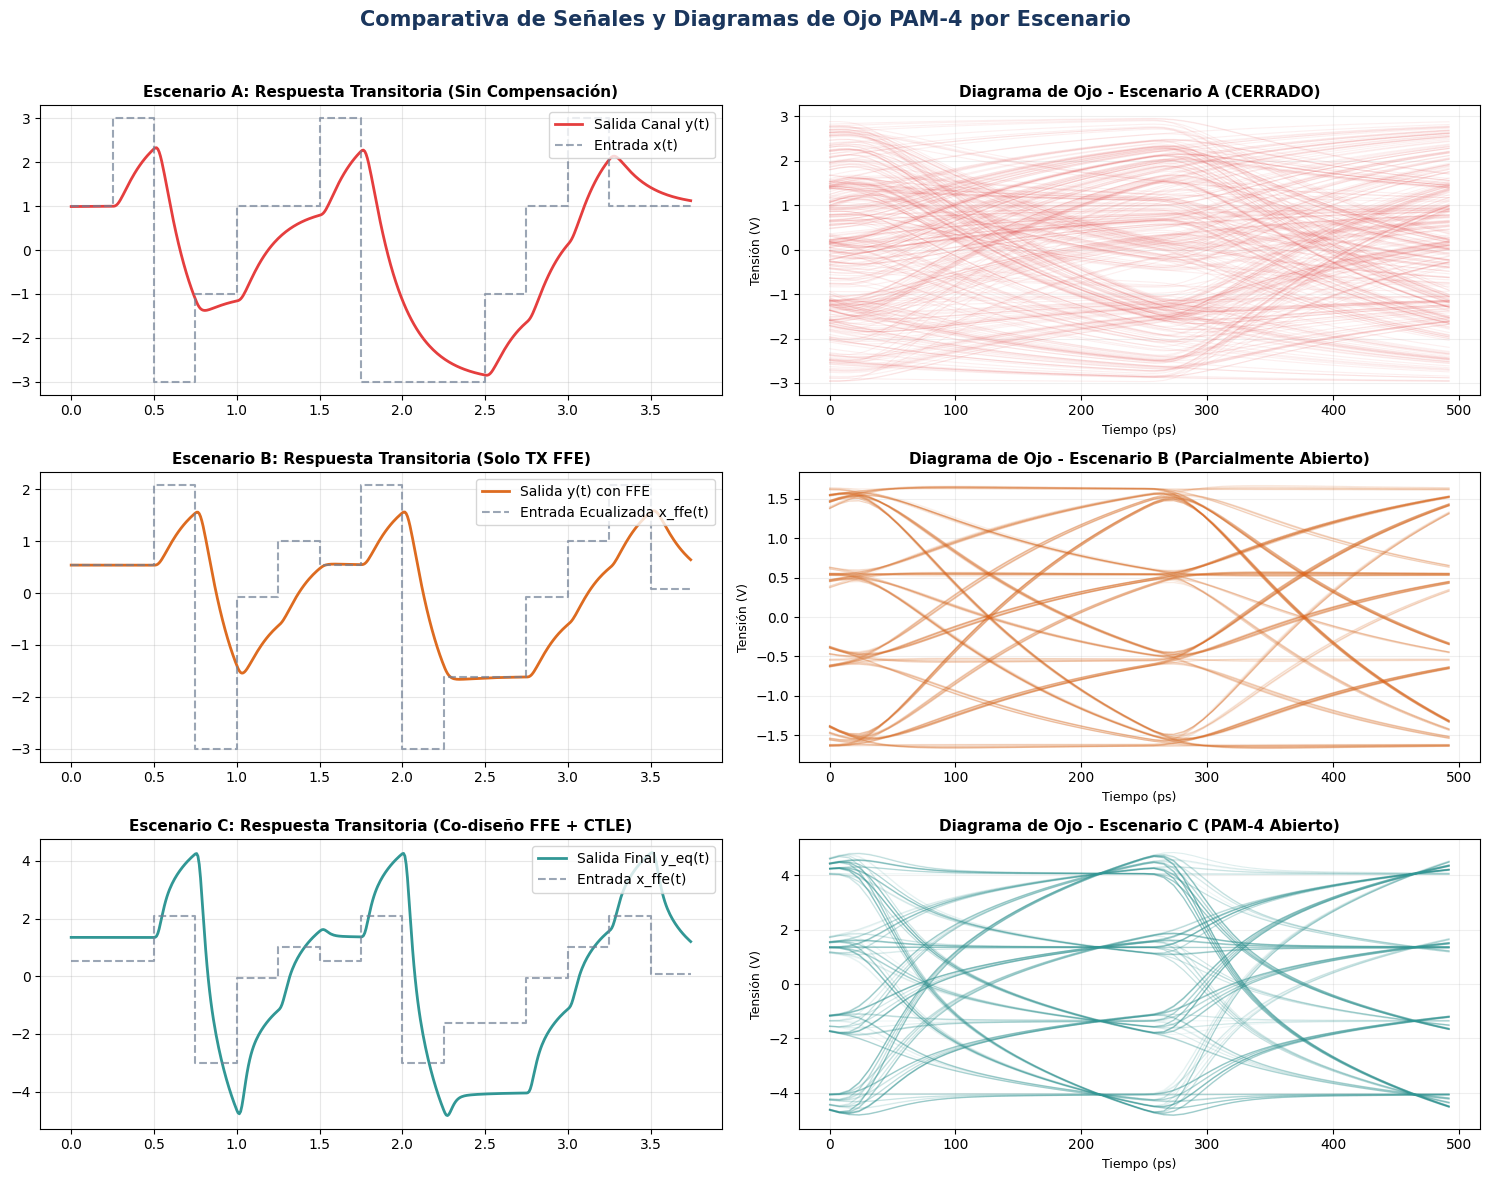

In [29]:
def graficar_diagrama_ojo(senal, sps_val, titulo, color, ax):
    """
    Grafica el diagrama de ojo superponiendo trozos de 2 símbolos de duración.
    """
    segmento_len = 2 * sps_val
    total_segmentos = (len(senal) - 100 * sps_val) // segmento_len
    t_ojo = np.arange(segmento_len) * (1e12 * ts)  # Eje en picosegundos

    for k in range(min(total_segmentos, 400)):
        idx = 100 * sps_val + k * segmento_len
        ax.plot(t_ojo, senal[idx:idx + segmento_len], color=color, alpha=0.08, linewidth=0.8)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel("Tiempo (ps)", fontsize=9)
    ax.set_ylabel("Tensión (V)", fontsize=9)
    ax.grid(True, alpha=0.2)

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle("Comparativa de Señales y Diagramas de Ojo PAM-4 por Escenario", fontsize=15, fontweight='bold', color='#1a365d')

# Ajustes estéticos
ventana_ver = slice(100 * sps, 115 * sps) # Ventana de 15 símbolos para visualización transitoria
t_ventana = (t_sym[ventana_ver] - ventana_ver.start * ts) * 1e9

# Escenario A
axes[0, 0].plot(t_ventana, y_a[ventana_ver], color='#e53e3e', linewidth=2, label='Salida Canal y(t)')
axes[0, 0].step(t_ventana, x_a[ventana_ver], where='post', color='#718096', linestyle='--', alpha=0.7, label='Entrada x(t)')
axes[0, 0].set_title("Escenario A: Respuesta Transitoria (Sin Compensación)", fontsize=11, fontweight='bold')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)
graficar_diagrama_ojo(y_a, sps, "Diagrama de Ojo - Escenario A (CERRADO)", '#e53e3e', axes[0, 1])

# Escenario B
axes[1, 0].plot(t_ventana, y_b[ventana_ver], color='#dd6b20', linewidth=2, label='Salida y(t) con FFE')
axes[1, 0].step(t_ventana, x_b[ventana_ver], where='post', color='#718096', linestyle='--', alpha=0.7, label='Entrada Ecualizada x_ffe(t)')
axes[1, 0].set_title("Escenario B: Respuesta Transitoria (Solo TX FFE)", fontsize=11, fontweight='bold')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)
graficar_diagrama_ojo(y_b, sps, "Diagrama de Ojo - Escenario B (Parcialmente Abierto)", '#dd6b20', axes[1, 1])

# Escenario C
axes[2, 0].plot(t_ventana, y_c[ventana_ver], color='#319795', linewidth=2, label='Salida Final y_eq(t)')
axes[2, 0].step(t_ventana, x_c[ventana_ver], where='post', color='#718096', linestyle='--', alpha=0.7, label='Entrada x_ffe(t)')
axes[2, 0].set_title("Escenario C: Respuesta Transitoria (Co-diseño FFE + CTLE)", fontsize=11, fontweight='bold')
axes[2, 0].legend(loc='upper right')
axes[2, 0].grid(True, alpha=0.3)
graficar_diagrama_ojo(y_c, sps, "Diagrama de Ojo - Escenario C (PAM-4 Abierto)", '#319795', axes[2, 1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 9. Análisis en el Dominio de la Frecuencia (FFT y Densidades Espectrales)
Evaluamos el comportamiento espectral de las señales para justificar físicamente la acción de filtrado paso-alto del CTLE al contrarrestar el roll-off paso-bajo del canal distribuido.

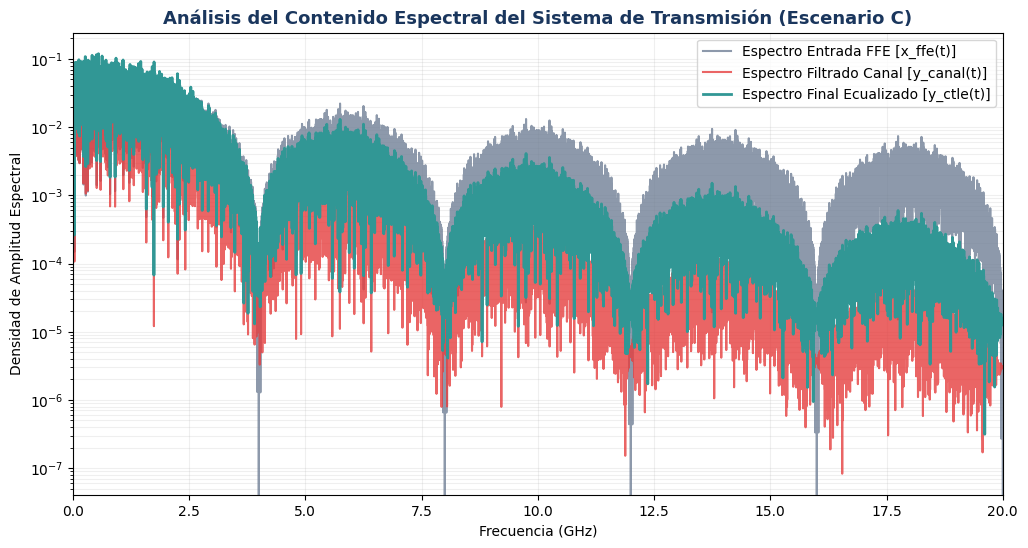

In [28]:
# Calcular FFT de las señales del Escenario C
N_fft = len(x_c)
f_axis = fft.fftfreq(N_fft, ts)

X_c_f = fft.fft(x_c)
Y_canal_f = fft.fft(y_c_canal)
Y_ctle_f = fft.fft(y_c)

# Solo frecuencias positivas hasta 20 GHz
idx_pos = (f_axis >= 0) & (f_axis <= 20e9)
f_pos = f_axis[idx_pos] / 1e9  # Convertido a GHz

plt.figure(figsize=(12, 6))
plt.semilogy(f_pos, np.abs(X_c_f[idx_pos])/N_fft, color='#718096', alpha=0.8, label='Espectro Entrada FFE [x_ffe(t)]')
plt.semilogy(f_pos, np.abs(Y_canal_f[idx_pos])/N_fft, color='#e53e3e', alpha=0.8, label='Espectro Filtrado Canal [y_canal(t)]')
plt.semilogy(f_pos, np.abs(Y_ctle_f[idx_pos])/N_fft, color='#319795', linewidth=2, label='Espectro Final Ecualizado [y_ctle(t)]')

plt.title("Análisis del Contenido Espectral del Sistema de Transmisión (Escenario C)", fontsize=13, fontweight='bold', color='#1a365d')
plt.xlabel("Frecuencia (GHz)")
plt.ylabel("Densidad de Amplitud Espectral")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(loc='upper right')
plt.xlim(0, 20)
plt.show()

## 10. Estimación del BER por Método Semi-Analítico (PAM-4)

**Por qué no contamos errores directamente.** Para *medir* un BER de $10^{-12}$ por Monte Carlo se necesitarían más de $10^{12}$ símbolos; contar 0 errores en unos cientos de símbolos **no demuestra** un BER bajo. Por eso usamos un método semi-analítico (ajuste Gaussiano del ojo + función $Q$).

**Ruido referido a la ENTRADA del receptor (clave para no inflar la ganancia).** El AWGN se inyecta en el dominio del tiempo a la **entrada del RX (salida del canal), ANTES del CTLE**. Así el CTLE amplifica señal *y* ruido por igual: su beneficio proviene únicamente del **peaking** (realce de alta frecuencia que contrarresta el roll-off del canal), no de una ganancia de banda ancha "gratis". Inyectar el ruido *después* del CTLE (como suele hacerse por descuido) regala SNR y produce BER artificialmente optimistas.

**Procedimiento:**
1. Inyectar AWGN ($\sigma_{in}$) a la salida del canal; para los escenarios con CTLE, filtrarlo junto con la señal.
2. Alinear la señal recibida con los símbolos transmitidos (fase + retardo por correlación cruzada).
3. Para cada nivel PAM-4 medir su media $\mu_k$ y su desviación total $\sigma_k$ (ISI residual **+** ruido filtrado) sobre las muestras ruidosas.
4. Extrapolar la probabilidad de error con $Q(\cdot)$ respecto a los umbrales (puntos medios entre niveles) y reportar la apertura del peor ojo.

In [27]:
# --- Ruido AWGN referido a la ENTRADA del receptor (antes del CTLE) + front-end RX ---
# Modelo correcto: el CTLE amplifica señal Y ruido por igual (su beneficio viene
# del peaking, no de ganancia gratis), y el receptor tiene ancho de banda finito
# (LPF anti-alias ~ tasa de simbolo) que limita el ruido fuera de banda.
sigma_in = 0.10          # V RMS, referido a la entrada del RX (salida del canal)
fc_rx = Rs_pam4          # Ancho de banda del front-end RX (~ tasa de simbolo)
np.random.seed(2026)     # reproducibilidad

# A y B no tienen CTLE: ruido de entrada -> front-end RX -> decisor
yA_n = aplicar_rx_lpf(y_a + np.random.normal(0.0, sigma_in, len(y_a)), ts, fc_rx)
yB_n = aplicar_rx_lpf(y_b + np.random.normal(0.0, sigma_in, len(y_b)), ts, fc_rx)

# C y D: el ruido entra ANTES del CTLE -> CTLE -> front-end RX
ruido_in = np.random.normal(0.0, sigma_in, len(y_c_canal))
_, yC_ctle, _ = signal.lsim(ctle_opt, U=y_c_canal + ruido_in, T=t_sym)
yC_n = aplicar_rx_lpf(yC_ctle, ts, fc_rx)

# DFE diseñado con la respuesta al pulso del enlace (sin ruido)
dfe_taps = disenar_dfe_zf(canal_lti, ctle_opt, mejores_parametros[1], sps, ts, n_taps=2)

# El ruido ya está en la forma de onda -> sigma_ruido = 0 dentro de evaluar_enlace
res_a = evaluar_enlace(yA_n, simbolos_pam4_ventana, sps, 0.0)
res_b = evaluar_enlace(yB_n, simbolos_pam4_ventana, sps, 0.0)
res_c = evaluar_enlace(yC_n, simbolos_pam4_ventana, sps, 0.0)
res_d = evaluar_enlace(yC_n, simbolos_pam4_ventana, sps, 0.0, dfe_taps=dfe_taps)

# Piso de credibilidad: la cola Gaussiana mas alla de ~7 sigma NO es confiable
# (el ruido real tiene colas no-gaussianas). Reportar BER por debajo de este piso
# como "libre de errores", NO como un numero exacto (evita sobre-afirmaciones tipo 1e-29).
BER_FLOOR = 1e-12
def fmt_ber(b):
    if b < BER_FLOOR:
        return f"< {BER_FLOOR:.0e} (libre de errores*)"
    return f"{b:.2e}"

print("=" * 74)
print("        RESULTADOS DE RENDIMIENTO (BER SEMI-ANALITICO)")
print("=" * 74)
print(f"Tasa: PAM-4 {Rs_baud/1e9:.1f} GBaud  |  sigma_in = {sigma_in} V RMS (entrada RX)  |  BW_rx = {fc_rx/1e9:.1f} GHz")
print(f"DFE (taps post-cursor, V/simbolo): {np.round(dfe_taps, 4)}\n")
for nombre, r in [("A  Canal critico, sin EQ      ", res_a),
                  ("B  Solo TX FFE                 ", res_b),
                  ("C  FFE + CTLE (co-diseno)      ", res_c),
                  ("D  FFE + CTLE + DFE            ", res_d)]:
    estado = "OJO ABIERTO" if r['eye_min'] > 0 else "ojo cerrado"
    print(f"Escenario {nombre} -> BER ~ {fmt_ber(r['ber']):>26}  | "
          f"apertura peor ojo (ISI+ruido): {r['eye_min']:+.3f} V  ({estado})")
print("-" * 74)
print("Nota: BER = ESTIMACION semi-analitica (modelo Gaussiano), no conteo Monte Carlo.")
print(f"(*) Por debajo de {BER_FLOOR:.0e} el modelo Gaussiano pierde validez (colas no-gaussianas);")
print("    se reporta como 'libre de errores', no como valor exacto.")
print("Ruido referido a la ENTRADA del RX + front-end de BW finito: el CTLE NO obtiene SNR gratis.")
print("A 4 GBaud el CTLE ya abre el ojo; el DFE aporta a tasas mas altas (ver barrido de tasa).")
print("=" * 74)

        RESULTADOS DE RENDIMIENTO (BER SEMI-ANALITICO)
Tasa: PAM-4 4.0 GBaud  |  sigma_in = 0.1 V RMS (entrada RX)  |  BW_rx = 4.0 GHz
DFE (taps post-cursor, V/simbolo): [-0.1122 -0.0062]

Escenario A  Canal critico, sin EQ       -> BER ~                   8.45e-02  | apertura peor ojo (ISI+ruido): -2.035 V  (ojo cerrado)
Escenario B  Solo TX FFE                  -> BER ~                   9.95e-10  | apertura peor ojo (ISI+ruido): +0.491 V  (OJO ABIERTO)
Escenario C  FFE + CTLE (co-diseno)       -> BER ~ < 1e-12 (libre de errores*)  | apertura peor ojo (ISI+ruido): +2.063 V  (OJO ABIERTO)
Escenario D  FFE + CTLE + DFE             -> BER ~ < 1e-12 (libre de errores*)  | apertura peor ojo (ISI+ruido): +1.657 V  (OJO ABIERTO)
--------------------------------------------------------------------------
Nota: BER = ESTIMACION semi-analitica (modelo Gaussiano), no conteo Monte Carlo.
(*) Por debajo de 1e-12 el modelo Gaussiano pierde validez (colas no-gaussianas);
    se reporta como 'libre d

## 11. Barrido de Tasa (Rate Sweep): el valor de la ecualización

El ancho de banda del canal (~0.95 GHz) fija un **límite duro sin ecualización**: a PAM-4, el enlace solo abre el ojo mientras Nyquist ($R_s/2$) no supere ese ancho de banda, es decir hasta **~1.9 GBaud**. La ecualización existe para **superar ese límite**.

Esta sección barre la tasa de símbolo y compara la BER de tres configuraciones —**sin EQ**, **FFE+CTLE** y **FFE+CTLE+DFE**— manteniendo fijo el co-diseño hallado por el DoE. El resultado cuantifica, en GBaud, cuánto alcance adicional aporta cada etapa:

- **Sin EQ:** muere cerca del límite del canal (~2 GBaud).
- **FFE+CTLE:** recupera pérdida más allá del −3 dB y empuja la tasa viable hacia arriba.
- **+DFE:** cancela la ISI de cola **sin amplificar ruido** (a diferencia del CTLE), extendiendo aún más el alcance.

Esta figura *tasa–alcance–ecualización* es la contribución central: convierte la observación de ancho de banda en una métrica de diseño accionable.

Barrido de tasa PAM-4 en curso (esto toma unos segundos)...


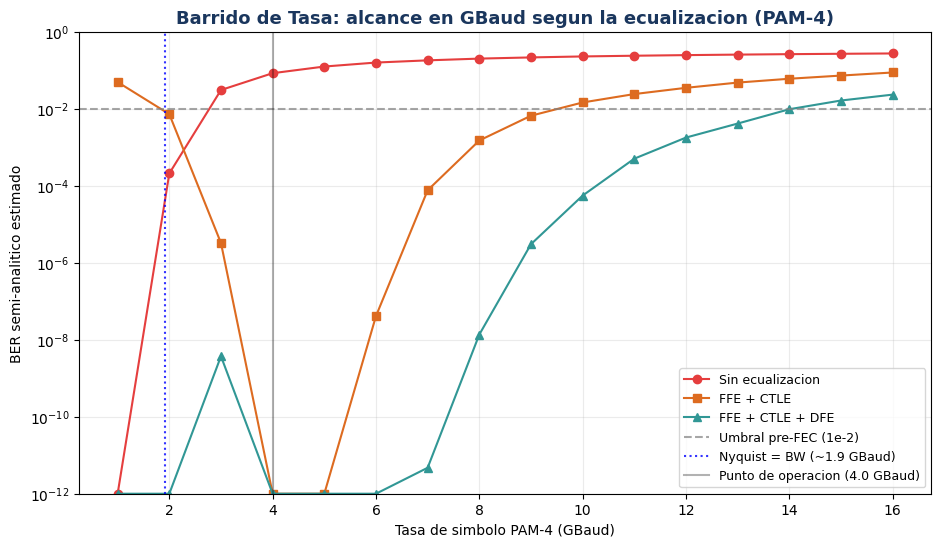

Tasa max viable (BER<=1e-2)  ->  sin EQ: 2.0 GBaud | FFE+CTLE: 9.0 GBaud | +DFE: 14.0 GBaud


In [26]:
# ===== Barrido de Tasa: BER vs GBaud para sin-EQ / FFE+CTLE / FFE+CTLE+DFE =====
# Ruido referido a la ENTRADA del RX (antes del CTLE) + front-end RX de BW finito,
# igual que en la tabla de BER. El BW del RX escala con la tasa (~ Rs).
tasas_baud = np.linspace(1e9, 16e9, 16)
R_sw, C_sw = 80.0, 5e-12
canal_sw = crear_canal_rc_distribuido(R_sw, C_sw, N=5)
w_z_opt, c_post_opt = mejores_parametros
sps_sw = 32
N_sym_sw = 2000

# Secuencia PRBS dedicada para el barrido (PRBS23, sin repetición)
bits_sw = generar_prbs(2 * N_sym_sw + 600, orden=23)
sym_sw = modular_pam4(bits_sw)[:N_sym_sw]

ber_none, ber_lin, ber_dfe = [], [], []
print("Barrido de tasa PAM-4 en curso (esto toma unos segundos)...")
np.random.seed(7)  # reproducibilidad del ruido del barrido
for Rs in tasas_baud:
    ts_sw = 1.0 / (Rs * sps_sw)
    fc_rx_sw = Rs                       # BW del front-end RX ~ tasa de simbolo
    xin0 = np.repeat(sym_sw, sps_sw)
    t_sw = np.arange(len(xin0)) * ts_sw
    n_muestras_sw = len(xin0)

    # (1) Sin EQ: ruido de entrada -> front-end RX
    _, y0, _ = signal.lsim(canal_sw, U=xin0, T=t_sw)
    y0n = aplicar_rx_lpf(y0 + np.random.normal(0.0, sigma_in, n_muestras_sw), ts_sw, fc_rx_sw)
    r0 = evaluar_enlace(y0n, sym_sw, sps_sw, 0.0)

    # (2) FFE + CTLE: ruido ANTES del CTLE -> CTLE -> front-end RX
    ffe = aplicar_ffe(sym_sw, 0.0, 1.0, c_post_opt)
    xin = np.repeat(ffe, sps_sw)
    _, yc1, _ = signal.lsim(canal_sw, U=xin, T=t_sw)
    ruido_in_sw = np.random.normal(0.0, sigma_in, len(yc1))
    ctle_sw = crear_ctle(w_z_opt, 2*np.pi*15e9, 2*np.pi*30e9, A_dc=2.5)
    _, ylin0, _ = signal.lsim(ctle_sw, U=yc1 + ruido_in_sw, T=t_sw)
    ylin = aplicar_rx_lpf(ylin0, ts_sw, fc_rx_sw)
    rl = evaluar_enlace(ylin, sym_sw, sps_sw, 0.0)

    # (3) + DFE (ZF desde la respuesta al pulso a esta tasa), misma señal ruidosa
    taps_sw = disenar_dfe_zf(canal_sw, ctle_sw, c_post_opt, sps_sw, ts_sw, n_taps=2)
    rd = evaluar_enlace(ylin, sym_sw, sps_sw, 0.0, dfe_taps=taps_sw)

    ber_none.append(r0['ber']); ber_lin.append(rl['ber']); ber_dfe.append(rd['ber'])

# Piso numerico para la escala logaritmica
piso = 1e-12
clip = lambda L: np.clip(np.array(L), piso, 1.0)
gb = tasas_baud / 1e9

plt.figure(figsize=(11, 6))
plt.semilogy(gb, clip(ber_none), 'o-', color='#e53e3e', label='Sin ecualizacion')
plt.semilogy(gb, clip(ber_lin),  's-', color='#dd6b20', label='FFE + CTLE')
plt.semilogy(gb, clip(ber_dfe),  '^-', color='#319795', label='FFE + CTLE + DFE')
plt.axhline(1e-2, color='gray', ls='--', alpha=0.7, label='Umbral pre-FEC (1e-2)')
plt.axvline(Rs_limite_sinEQ_GBaud, color='blue', ls=':', alpha=0.8,
            label=f'Nyquist = BW (~{Rs_limite_sinEQ_GBaud:.1f} GBaud)')
plt.axvline(Rs_baud/1e9, color='black', ls='-', alpha=0.3,
            label=f'Punto de operacion ({Rs_baud/1e9:.1f} GBaud)')
plt.title('Barrido de Tasa: alcance en GBaud segun la ecualizacion (PAM-4)',
          fontsize=13, fontweight='bold', color='#1a365d')
plt.xlabel('Tasa de simbolo PAM-4 (GBaud)')
plt.ylabel('BER semi-analitico estimado')
plt.ylim(piso, 1)
plt.grid(True, which='both', alpha=0.25)
plt.legend(loc='lower right', fontsize=9)
plt.show()

# Tasa maxima viable (por debajo del umbral pre-FEC) para cada configuracion
def tasa_max(bers, umbral=1e-2):
    ok = gb[np.array(bers) <= umbral]
    return ok.max() if len(ok) else 0.0
print(f"Tasa max viable (BER<=1e-2)  ->  sin EQ: {tasa_max(ber_none):.1f} GBaud | "
      f"FFE+CTLE: {tasa_max(ber_lin):.1f} GBaud | +DFE: {tasa_max(ber_dfe):.1f} GBaud")

## 12. Resultado exploratorio: PAM-8 como banco de pruebas exigente (stress test)

PAM-8 **no** es un esquema de despliegue habitual en cobre (penalización de SNR). Aquí se usa con una justificación **técnica**, no de uso: con el **mismo presupuesto de amplitud** (pico ±3 V, igual que PAM-4), 8 niveles dejan los ojos **≈2.3× más estrechos**. Es decir, un **entorno más agresivo** que sirve para dos cosas:

1. **Verificar la generalización** de la *misma* cadena de co-diseño (FFE+CTLE+DFE + receptor realista) a una constelación más densa, sin re-optimizar (la ecualización compensa el **canal**, no la constelación).
2. **Cuantificar el compromiso orden-vs-alcance:** PAM-8 transporta 3 bit/símbolo (vs 2 de PAM-4) pero es viable a menor tasa. La figura de **throughput neto (Gb/s) = tasa viable × bits/símbolo** revela cuál maximiza el caudal real sobre este canal.

Se mantienen fijos el canal, el co-diseño hallado por el DoE, el ruido y el front-end del receptor.

Barrido de tasa PAM-8 (stress test) en curso...


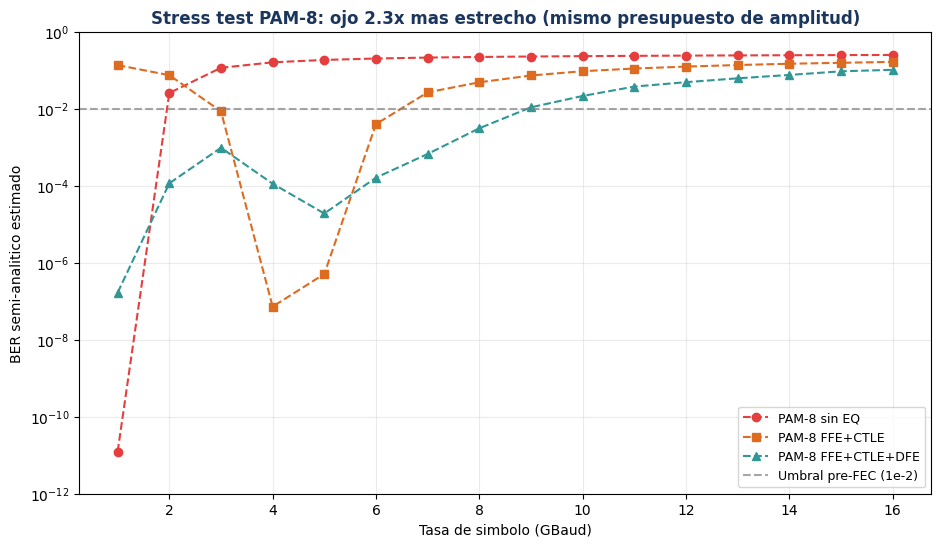

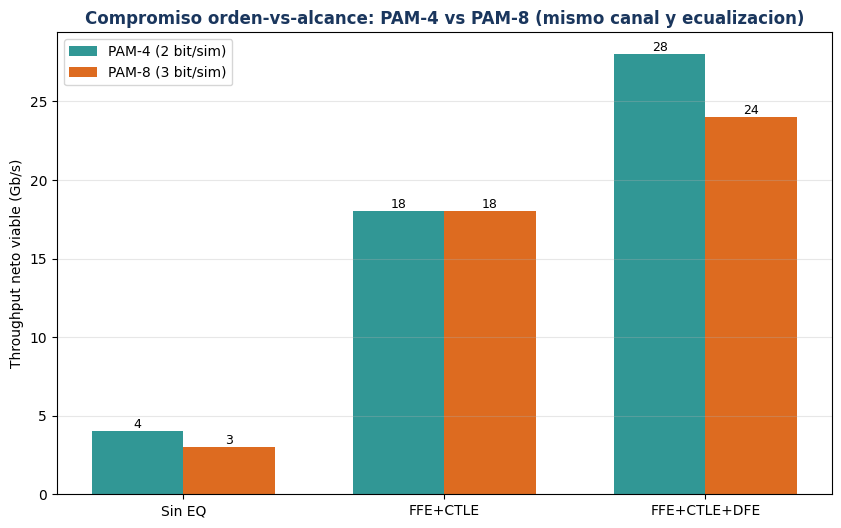

Tasa viable (GBaud)  PAM-4: ['2', '9', '14']  PAM-8: ['1', '6', '8']
Throughput neto (Gb/s) PAM-4: ['4', '18', '28']  PAM-8: ['3', '18', '24']
Lectura: PAM-8 lleva 3 bit/sim pero su menor alcance suele NO compensar; el co-diseno
de ecualizacion sigue ordenando A<B<C tambien en PAM-8 -> la metodologia GENERALIZA.


In [25]:
# ===== STRESS TEST: PAM-8 (resultado exploratorio) =====
# Justificacion (NO por despliegue, que es marginal en cobre): con el MISMO presupuesto
# de amplitud (pico +/-3 V que PAM-4), 8 niveles producen ojos ~2.3x mas estrechos.
# Es un entorno mas AGRESIVO para verificar si el MISMO co-diseno de ecualizacion
# (FFE+CTLE+DFE + receptor realista) GENERALIZA a constelaciones densas, y revela el
# compromiso ORDEN-vs-ALCANCE (mas bits/simbolo a costa de menor tasa viable).

NIVELES_PAM8 = np.linspace(-3.0, 3.0, 8)   # mismo pico (+/-3 V) que PAM-4; espaciado 6/7

def modular_mpam(bits, niveles):
    """Modula bits en M-PAM con mapeo Gray (M=len(niveles), potencia de 2)."""
    M = len(niveles); k = int(round(np.log2(M)))
    r = len(bits) % k
    if r:
        bits = np.append(bits, np.zeros(k - r, dtype=bits.dtype))
    groups = bits.reshape(-1, k)
    pesos = (1 << np.arange(k - 1, -1, -1))          # MSB-first
    etiqueta = groups.dot(pesos).astype(int)         # 0..M-1
    gray = np.array([i ^ (i >> 1) for i in range(M)]) # gray[i] = etiqueta del nivel i
    lab2idx = np.empty(M, dtype=int); lab2idx[gray] = np.arange(M)
    return niveles[lab2idx[etiqueta]]

def estadisticas_mpam(muestras, tx, niveles):
    M = len(niveles); mu = np.zeros(M); s = np.zeros(M); cnt = np.zeros(M, dtype=int)
    for k, lv in enumerate(niveles):
        sel = muestras[np.isclose(tx, lv)]
        cnt[k] = len(sel)
        if len(sel) >= 2: mu[k] = sel.mean(); s[k] = sel.std()
        elif len(sel) == 1: mu[k] = sel[0]
    return mu, s, cnt

def _decidir_mpam(yk, escala, niveles):
    lv = niveles * escala
    return niveles[int(np.argmin(np.abs(yk - lv)))]

def evaluar_mpam(y, tx_syms, sps_val, niveles, dfe_taps=None, n_descartar=80):
    """BER semi-analitico (modelo Gaussiano) para M-PAM. Ruido ya incluido en 'y'."""
    M = len(niveles); kbits = int(round(np.log2(M)))
    m, tx = muestrear_alineado(y, tx_syms, sps_val)
    m, tx = m[n_descartar:], tx[n_descartar:]
    mu0, _, _ = estadisticas_mpam(m, tx, niveles)
    o0 = np.argsort(mu0)
    escala = (mu0[o0][-1] - mu0[o0][0]) / (niveles.max() - niveles.min())
    escala = escala if escala > 1e-9 else 1.0
    if dfe_taps is not None and len(dfe_taps) > 0:
        Nt = len(dfe_taps); hist = [0.0] * Nt; m_eq = np.empty_like(m)
        for i in range(len(m)):
            fb = sum(dfe_taps[j] * hist[j] for j in range(Nt))
            yk = m[i] - fb; m_eq[i] = yk
            hist = [_decidir_mpam(yk, escala, niveles)] + hist[:-1]
        m = m_eq
    mu, s, cnt = estadisticas_mpam(m, tx, niveles)
    o = np.argsort(mu); mu, s, cnt = mu[o], s[o], cnt[o]
    thr = (mu[:-1] + mu[1:]) / 2.0; eps = 1e-300
    Pe = np.zeros(M)
    Pe[0] = Q((thr[0] - mu[0]) / (s[0] + eps))
    for kk in range(1, M - 1):
        Pe[kk] = Q((mu[kk] - thr[kk-1]) / (s[kk] + eps)) + Q((thr[kk] - mu[kk]) / (s[kk] + eps))
    Pe[M-1] = Q((mu[M-1] - thr[M-2]) / (s[M-1] + eps))
    tot = cnt.sum(); w = cnt / tot if tot > 0 else np.full(M, 1.0 / M)
    ser = float(np.sum(w * Pe)); ber = ser / kbits
    ap = (mu[1:] - 3*s[1:]) - (mu[:-1] + 3*s[:-1])
    return {"ber": ber, "ser": ser, "eye_min": float(np.min(ap))}

# --- Barrido de tasa para PAM-8 (mismo canal, mismo co-diseno EQ, mismo receptor) ---
N8 = 2000
bits8 = generar_prbs(3 * N8 + 600, orden=23)
sym8 = modular_mpam(bits8, NIVELES_PAM8)[:N8]

ber8_none, ber8_lin, ber8_dfe = [], [], []
print("Barrido de tasa PAM-8 (stress test) en curso...")
np.random.seed(11)
for Rs in tasas_baud:
    ts_sw = 1.0 / (Rs * sps_sw); fc = Rs
    xin0 = np.repeat(sym8, sps_sw); t_sw = np.arange(len(xin0)) * ts_sw

    _, y0, _ = signal.lsim(canal_sw, U=xin0, T=t_sw)
    y0n = aplicar_rx_lpf(y0 + np.random.normal(0.0, sigma_in, len(xin0)), ts_sw, fc)
    r0 = evaluar_mpam(y0n, sym8, sps_sw, NIVELES_PAM8)

    ffe = aplicar_ffe(sym8, 0.0, 1.0, c_post_opt); xin = np.repeat(ffe, sps_sw)
    _, yc1, _ = signal.lsim(canal_sw, U=xin, T=t_sw)
    rin = np.random.normal(0.0, sigma_in, len(yc1))
    ctle_sw = crear_ctle(w_z_opt, 2*np.pi*15e9, 2*np.pi*30e9, A_dc=2.5)
    _, ylin0, _ = signal.lsim(ctle_sw, U=yc1 + rin, T=t_sw)
    ylin = aplicar_rx_lpf(ylin0, ts_sw, fc)
    rl = evaluar_mpam(ylin, sym8, sps_sw, NIVELES_PAM8)

    taps = disenar_dfe_zf(canal_sw, ctle_sw, c_post_opt, sps_sw, ts_sw, n_taps=2)
    rd = evaluar_mpam(ylin, sym8, sps_sw, NIVELES_PAM8, dfe_taps=taps)

    ber8_none.append(r0['ber']); ber8_lin.append(rl['ber']); ber8_dfe.append(rd['ber'])

# --- Figura 1: BER vs GBaud para PAM-8 ---
plt.figure(figsize=(11, 6))
plt.semilogy(gb, clip(ber8_none), 'o--', color='#e53e3e', label='PAM-8 sin EQ')
plt.semilogy(gb, clip(ber8_lin),  's--', color='#dd6b20', label='PAM-8 FFE+CTLE')
plt.semilogy(gb, clip(ber8_dfe),  '^--', color='#319795', label='PAM-8 FFE+CTLE+DFE')
plt.axhline(1e-2, color='gray', ls='--', alpha=0.7, label='Umbral pre-FEC (1e-2)')
plt.title('Stress test PAM-8: ojo 2.3x mas estrecho (mismo presupuesto de amplitud)',
          fontsize=12, fontweight='bold', color='#1a365d')
plt.xlabel('Tasa de simbolo (GBaud)'); plt.ylabel('BER semi-analitico estimado')
plt.ylim(piso, 1); plt.grid(True, which='both', alpha=0.25); plt.legend(loc='lower right', fontsize=9)
plt.show()

# --- Figura 2: Throughput neto (Gb/s) vs alcance: PAM-4 vs PAM-8 ---
def t_max(B, umbral=1e-2):
    ok = gb[np.array(B) <= umbral]
    return ok.max() if len(ok) else 0.0
cfgs = ['Sin EQ', 'FFE+CTLE', 'FFE+CTLE+DFE']
rate4 = [t_max(ber_none), t_max(ber_lin), t_max(ber_dfe)]          # GBaud PAM-4
rate8 = [t_max(ber8_none), t_max(ber8_lin), t_max(ber8_dfe)]       # GBaud PAM-8
thr4 = [2 * r for r in rate4]     # 2 bit/simbolo
thr8 = [3 * r for r in rate8]     # 3 bit/simbolo

x = np.arange(3); w = 0.35
plt.figure(figsize=(10, 6))
plt.bar(x - w/2, thr4, w, color='#319795', label='PAM-4 (2 bit/sim)')
plt.bar(x + w/2, thr8, w, color='#dd6b20', label='PAM-8 (3 bit/sim)')
for i in range(3):
    plt.text(x[i]-w/2, thr4[i], f'{thr4[i]:.0f}', ha='center', va='bottom', fontsize=9)
    plt.text(x[i]+w/2, thr8[i], f'{thr8[i]:.0f}', ha='center', va='bottom', fontsize=9)
plt.xticks(x, cfgs); plt.ylabel('Throughput neto viable (Gb/s)')
plt.title('Compromiso orden-vs-alcance: PAM-4 vs PAM-8 (mismo canal y ecualizacion)',
          fontsize=12, fontweight='bold', color='#1a365d')
plt.legend(); plt.grid(True, axis='y', alpha=0.3); plt.show()

print("Tasa viable (GBaud)  PAM-4:", [f'{r:.0f}' for r in rate4], " PAM-8:", [f'{r:.0f}' for r in rate8])
print("Throughput neto (Gb/s) PAM-4:", [f'{t:.0f}' for t in thr4], " PAM-8:", [f'{t:.0f}' for t in thr8])
print("Lectura: PAM-8 lleva 3 bit/sim pero su menor alcance suele NO compensar; el co-diseno")
print("de ecualizacion sigue ordenando A<B<C tambien en PAM-8 -> la metodologia GENERALIZA.")

Multi-semilla (5 semillas) en curso...


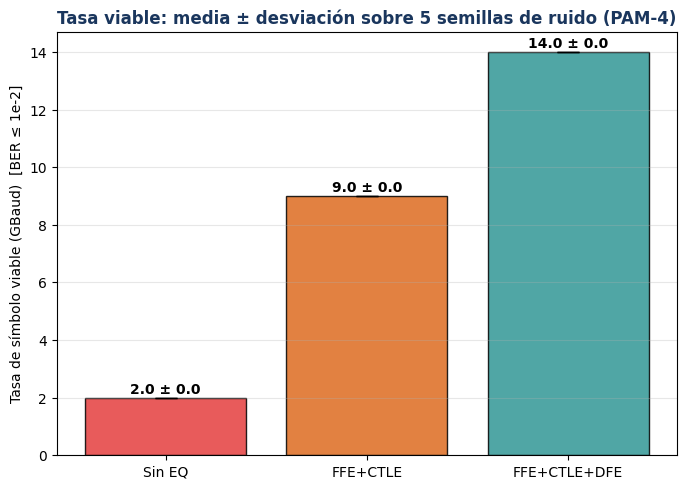

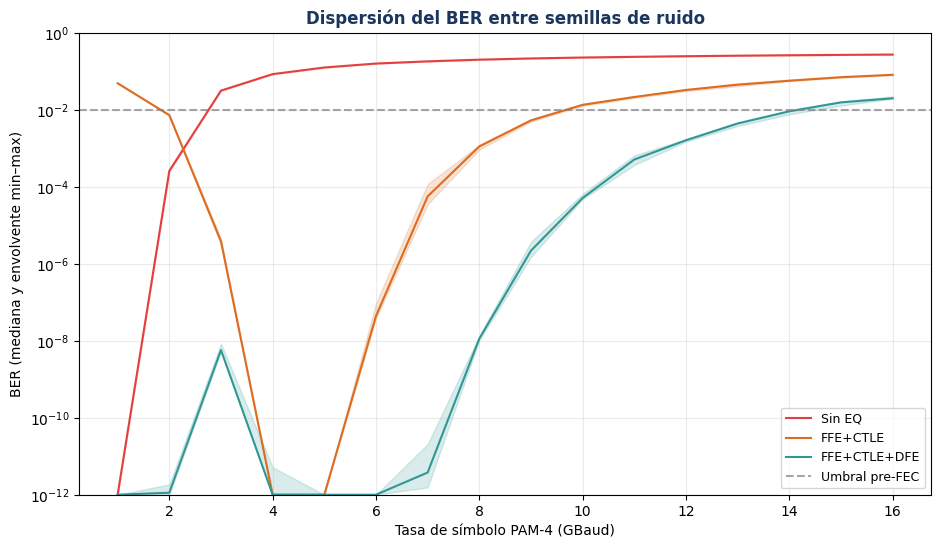

Tasa viable (GBaud)  media ± std:
  Sin EQ        : 2.0 ± 0.0
  FFE+CTLE      : 9.0 ± 0.0
  FFE+CTLE+DFE  : 14.0 ± 0.0


In [24]:
# ===== Robustez multi-semilla: tasa viable con barras de error (PAM-4) =====
# Repite el barrido variando solo el AWGN (varias semillas) y reporta la tasa
# viable como media +/- desviacion. Canal/EQ/senal son deterministas: se precomputan
# una vez por tasa y se les suma ruido distinto por semilla (linealidad del CTLE).
SEMILLAS = [1, 7, 11, 23, 42]      # 5 realizaciones de ruido
N_sym_mc = 1500
UMBRAL = 1e-2                       # pre-FEC
bits_mc = generar_prbs(2 * N_sym_mc + 600, orden=23)
sym_mc  = modular_pam4(bits_mc)[:N_sym_mc]

# --- Precomputo determinista por tasa (senal limpia, sin ruido) ---
det = []
for Rs in tasas_baud:
      ts_sw = 1.0 / (Rs * sps_sw)
      t_sw  = np.arange(N_sym_mc * sps_sw) * ts_sw
      _, y0_sig, _   = signal.lsim(canal_sw, U=np.repeat(sym_mc, sps_sw), T=t_sw)          # no-EQ
      xin = np.repeat(aplicar_ffe(sym_mc, 0.0, 1.0, c_post_opt), sps_sw)
      _, yc1, _      = signal.lsim(canal_sw, U=xin, T=t_sw)                                # canal (pre-CTLE)
      ctle = crear_ctle(w_z_opt, 2*np.pi*15e9, 2*np.pi*30e9, A_dc=2.5)
      _, ylin_sig, _ = signal.lsim(ctle, U=yc1, T=t_sw)                                    # CTLE(senal)
      taps = disenar_dfe_zf(canal_sw, ctle, c_post_opt, sps_sw, ts_sw, n_taps=2)
      det.append((Rs, ts_sw, t_sw, y0_sig, yc1, ctle, ylin_sig, taps))

# --- Barrido por semilla ---
ber_mc = {'none': [], 'lin': [], 'dfe': []}
print(f"Multi-semilla ({len(SEMILLAS)} semillas) en curso...")
for sd in SEMILLAS:
    rng = np.random.default_rng(sd)
    bn, bl, bd = [], [], []
    for (Rs, ts_sw, t_sw, y0_sig, yc1, ctle, ylin_sig, taps) in det:
          fc = Rs
          # (1) sin EQ: ruido a la salida del canal
          y0n = aplicar_rx_lpf(y0_sig + rng.normal(0, sigma_in, len(y0_sig)), ts_sw, fc)
          bn.append(evaluar_enlace(y0n, sym_mc, sps_sw, 0.0)['ber'])
          # (2) FFE+CTLE: ruido ANTES del CTLE -> CTLE(ruido) por linealidad
          _, ctle_noise, _ = signal.lsim(ctle, U=rng.normal(0, sigma_in, len(yc1)), T=t_sw)
          ylin = aplicar_rx_lpf(ylin_sig + ctle_noise, ts_sw, fc)
          bl.append(evaluar_enlace(ylin, sym_mc, sps_sw, 0.0)['ber'])
          # (3) + DFE (misma senal ruidosa)
          bd.append(evaluar_enlace(ylin, sym_mc, sps_sw, 0.0, dfe_taps=taps)['ber'])
    ber_mc['none'].append(bn); ber_mc['lin'].append(bl); ber_mc['dfe'].append(bd)

# --- Procesado: tasa viable por semilla -> media +/- std ---
gb_mc = tasas_baud / 1e9
def stack(L): return np.clip(np.array(L), 1e-12, 1.0)   # (n_semillas, n_tasas)
Bn, Bl, Bd = stack(ber_mc['none']), stack(ber_mc['lin']), stack(ber_mc['dfe'])
def viables(B):
      return np.array([(gb_mc[row <= UMBRAL].max() if np.any(row <= UMBRAL) else 0.0) for row in B])
vn, vl, vd = viables(Bn), viables(Bl), viables(Bd)
cfgs   = ['Sin EQ', 'FFE+CTLE', 'FFE+CTLE+DFE']
medias = [vn.mean(), vl.mean(), vd.mean()]
desv   = [vn.std(),  vl.std(),  vd.std()]

# --- Figura 1: tasa viable con barras de error ---
plt.figure(figsize=(8, 5.5))
plt.bar(cfgs, medias, yerr=desv, capsize=8, color=['#e53e3e', '#dd6b20', '#319795'],
          edgecolor='k', alpha=0.85)
for i, (m, s) in enumerate(zip(medias, desv)):
      plt.text(i, m + s + 0.15, f'{m:.1f} ± {s:.1f}', ha='center', fontsize=10, fontweight='bold')
plt.ylabel('Tasa de símbolo viable (GBaud)  [BER ≤ 1e-2]')
plt.title(f'Tasa viable: media ± desviación sobre {len(SEMILLAS)} semillas de ruido (PAM-4)',
            fontsize=12, fontweight='bold', color='#1a365d')
plt.grid(True, axis='y', alpha=0.3); plt.show()

# --- Figura 2: BER vs GBaud, mediana + envolvente min-max ---
plt.figure(figsize=(11, 6))
for B, col, lab in [(Bn, '#e53e3e', 'Sin EQ'), (Bl, '#dd6b20', 'FFE+CTLE'), (Bd, '#319795', 'FFE+CTLE+DFE')]:
      plt.semilogy(gb_mc, np.median(B, 0), '-', color=col, label=lab)
      plt.fill_between(gb_mc, B.min(0), B.max(0), color=col, alpha=0.18)
plt.axhline(UMBRAL, color='gray', ls='--', alpha=0.7, label='Umbral pre-FEC')
plt.ylim(1e-12, 1); plt.grid(True, which='both', alpha=0.25); plt.legend(loc='lower right', fontsize=9)
plt.xlabel('Tasa de símbolo PAM-4 (GBaud)'); plt.ylabel('BER (mediana y envolvente min–max)')
plt.title('Dispersión del BER entre semillas de ruido', fontsize=12, fontweight='bold', color='#1a365d')
plt.show()

print("Tasa viable (GBaud)  media ± std:")
for c, m, s in zip(cfgs, medias, desv):
      print(f"  {c:14s}: {m:.1f} ± {s:.1f}")

In [18]:
print("Tasa viable (GBaud)  media ± std:")
for c, m, s in zip(cfgs, medias, desv):
      print(f"  {c:14s}: {m:.1f} ± {s:.1f}")

Tasa viable (GBaud)  media ± std:
  Sin EQ        : 2.0 ± 0.0
  FFE+CTLE      : 9.0 ± 0.0
  FFE+CTLE+DFE  : 12.0 ± 0.0


Robustez: 30 realizaciones (patron + ruido)...


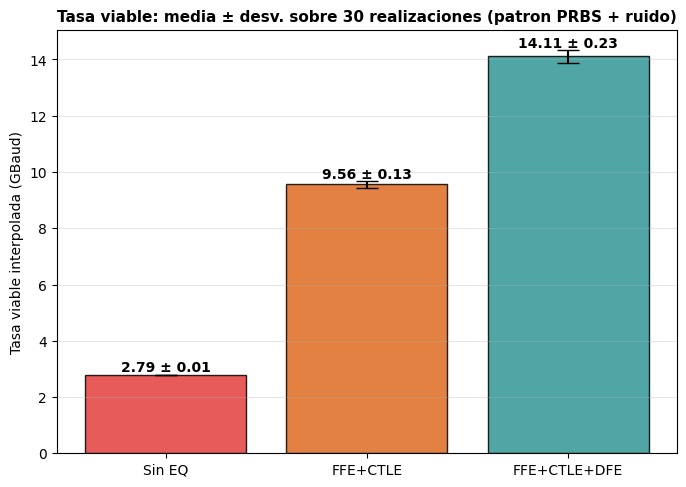

Tasa viable interpolada (GBaud) media ± std:
  Sin EQ        : 2.79 ± 0.01
  FFE+CTLE      : 9.56 ± 0.13
  FFE+CTLE+DFE  : 14.11 ± 0.23


In [23]:
# ===== Robustez: variar PATRON (PRBS) + ruido, con tasa viable INTERPOLADA =====
N_REAL = 30                 # realizaciones: cada una con patron PRBS distinto + ruido distinto
N_sym_mc = 1500
UMBRAL = 1e-2
bits_pool = generar_prbs(N_REAL * (2 * N_sym_mc) + 4000, orden=23)  # ventanas no solapadas

def viable_interp(b, gbx, umbral=UMBRAL):
      """Tasa donde BER cruza el umbral, interpolando en log10(BER) entre puntos de rejilla."""
      b = np.clip(np.asarray(b, float), 1e-300, 1.0)
      lb = np.log10(b); lt = np.log10(umbral); below = lb <= lt
      if not below.any(): return 0.0
      if below.all():     return float(gbx[-1])
      cruce = None
      for i in range(len(gbx) - 1):
          if below[i] and not below[i + 1]:
              frac = (lt - lb[i]) / (lb[i + 1] - lb[i])
              cruce = gbx[i] + frac * (gbx[i + 1] - gbx[i])
      return float(cruce) if cruce is not None else float(gbx[below][-1])

gb_mc = tasas_baud / 1e9
Vn, Vl, Vd = [], [], []
print(f"Robustez: {N_REAL} realizaciones (patron + ruido)...")
for r in range(N_REAL):
    bslice = bits_pool[r*2*N_sym_mc : r*2*N_sym_mc + 2*N_sym_mc + 200]
    sym_r = modular_pam4(bslice)[:N_sym_mc]
    rng = np.random.default_rng(1000 + r)
    bn, bl, bd = [], [], []
    for Rs in tasas_baud:
          ts_sw = 1.0 / (Rs * sps_sw); fc = Rs
          t_sw = np.arange(N_sym_mc * sps_sw) * ts_sw
          _, y0, _ = signal.lsim(canal_sw, U=np.repeat(sym_r, sps_sw), T=t_sw)
          y0n = aplicar_rx_lpf(y0 + rng.normal(0, sigma_in, len(y0)), ts_sw, fc)
          bn.append(evaluar_enlace(y0n, sym_r, sps_sw, 0.0)['ber'])
          xin = np.repeat(aplicar_ffe(sym_r, 0.0, 1.0, c_post_opt), sps_sw)
          _, yc1, _ = signal.lsim(canal_sw, U=xin, T=t_sw)
          ctle = crear_ctle(w_z_opt, 2*np.pi*15e9, 2*np.pi*30e9, A_dc=2.5)
          _, yl0, _ = signal.lsim(ctle, U=yc1 + rng.normal(0, sigma_in, len(yc1)), T=t_sw)
          yl = aplicar_rx_lpf(yl0, ts_sw, fc)
          bl.append(evaluar_enlace(yl, sym_r, sps_sw, 0.0)['ber'])
          taps = disenar_dfe_zf(canal_sw, ctle, c_post_opt, sps_sw, ts_sw, n_taps=2)
          bd.append(evaluar_enlace(yl, sym_r, sps_sw, 0.0, dfe_taps=taps)['ber'])
    Vn.append(viable_interp(bn, gb_mc)); Vl.append(viable_interp(bl, gb_mc)); Vd.append(viable_interp(bd, gb_mc))

Vn, Vl, Vd = np.array(Vn), np.array(Vl), np.array(Vd)
cfgs = ['Sin EQ', 'FFE+CTLE', 'FFE+CTLE+DFE']
med = [Vn.mean(), Vl.mean(), Vd.mean()]; sd = [Vn.std(), Vl.std(), Vd.std()]

plt.figure(figsize=(8, 5.5))
plt.bar(cfgs, med, yerr=sd, capsize=8, color=['#e53e3e','#dd6b20','#319795'], edgecolor='k', alpha=0.85)
for i,(m,s) in enumerate(zip(med,sd)):
      plt.text(i, m+s+0.1, f'{m:.2f} ± {s:.2f}', ha='center', fontsize=10, fontweight='bold')
plt.ylabel('Tasa viable interpolada (GBaud)')
plt.title(f'Tasa viable: media ± desv. sobre {N_REAL} realizaciones (patron PRBS + ruido)', fontsize=11, fontweight='bold')
plt.grid(True, axis='y', alpha=0.3); plt.show()

print("Tasa viable interpolada (GBaud) media ± std:")
for c,m,s in zip(cfgs, med, sd): print(f"  {c:14s}: {m:.2f} ± {s:.2f}")